In [1]:
## IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
import warnings

In [2]:
## LOAD DATA
df = pd.read_csv(r"C:\Users\Admin\Downloads\exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
## CONVERT DATE + SET INDEX
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

# Fix frequency (removes warning)
df = df.asfreq('D')

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


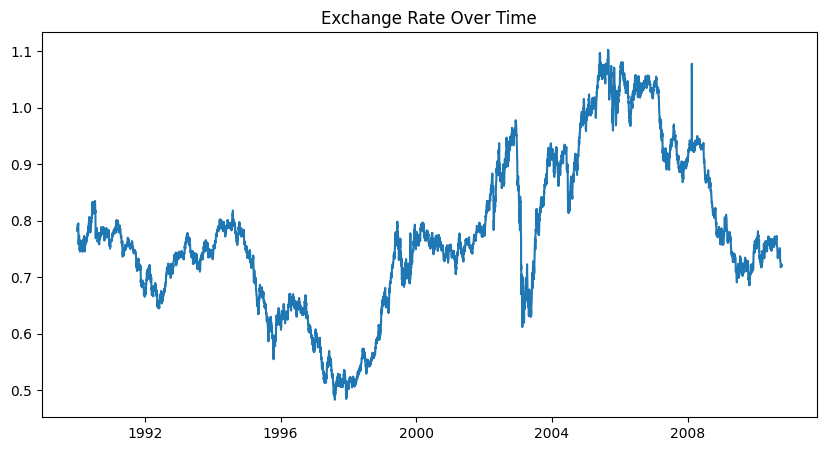

In [4]:
## PLOT ORIGINAL DATA
plt.figure(figsize=(10,5))
plt.plot(df['Ex_rate'])
plt.title("Exchange Rate Over Time")
plt.show()

In [5]:
## CHECK STATIONARITY
result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381414
p-value: 0.4492327353597959


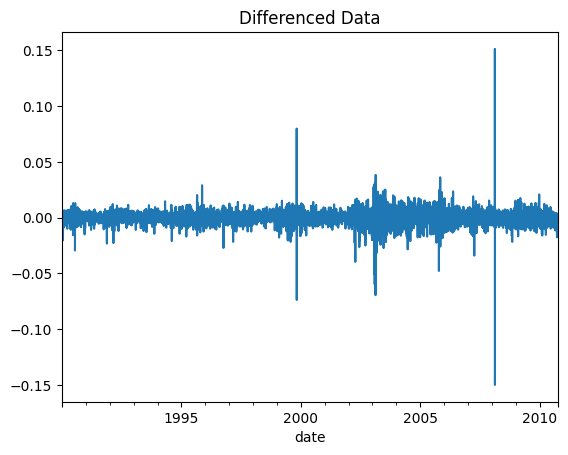

In [6]:
## DIFFERENCING
df['diff'] = df['Ex_rate'].diff()

df['diff'].dropna().plot(title="Differenced Data")
plt.show()

In [7]:
result = adfuller(df['diff'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -99.3934312011863
p-value: 0.0


In [8]:
## SPLIT DATA
train = df['Ex_rate'][:-30]
test = df['Ex_rate'][-30:]

In [10]:
model = ARIMA(train, order=(1,1,1))   # ← REMOVE #

model_fit = model.fit()

pred = model_fit.forecast(steps=30)

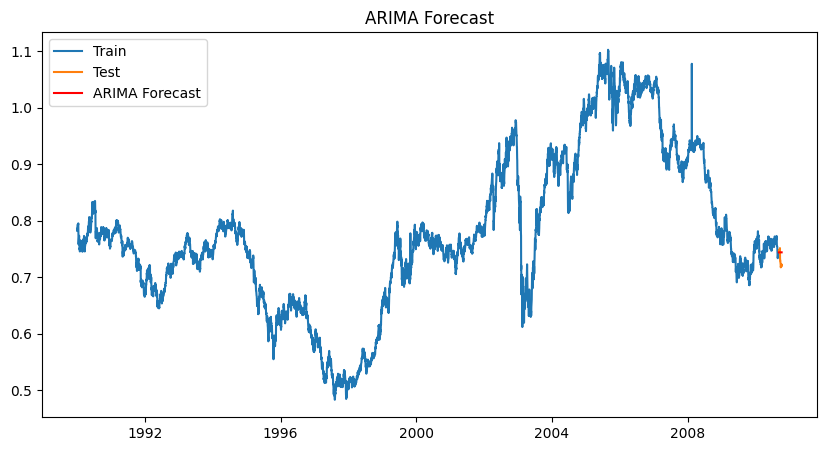

In [11]:
## PLOT ARIMA RESULT
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(pred, label='ARIMA Forecast', color='red')

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [12]:
## EXPONENTIAL SMOOTHING
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model2 = ExponentialSmoothing(train, trend='add')
fit2 = model2.fit()

pred2 = fit2.forecast(30)

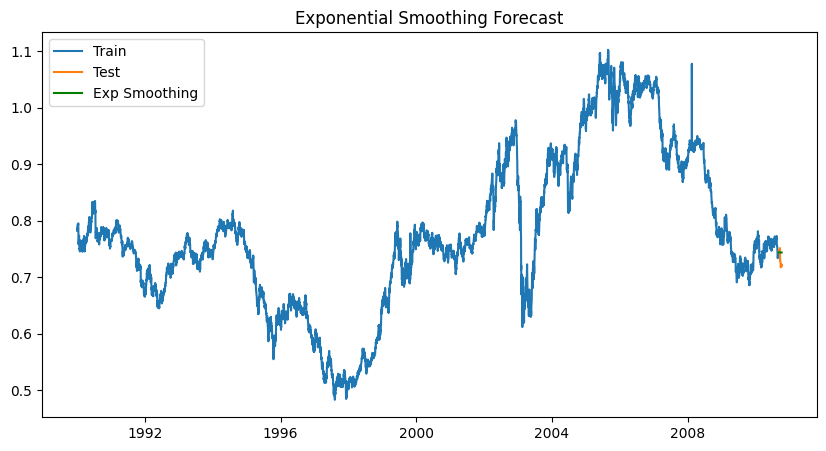

In [13]:
## PLOT EXPONENTIAL SMOOTHING
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(pred2, label='Exp Smoothing', color='green')

plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

In [14]:
## FINAL COMPARISON
from sklearn.metrics import mean_absolute_error

print("ARIMA MAE:", mean_absolute_error(test, pred))
print("Exp Smoothing MAE:", mean_absolute_error(test, pred2))

ARIMA MAE: 0.013494600805753154
Exp Smoothing MAE: 0.013423166100516226


## Conclusion
In this project, we performed time series analysis on exchange rate data using ARIMA and Exponential Smoothing models.

Initially, the data was found to be non-stationary based on the ADF test. After applying differencing, the data became stationary.

The ARIMA(1,1,1) model was built and used for forecasting. Additionally, the Exponential Smoothing model with additive trend was applied.

Both models performed well in forecasting future values. However, based on Mean Absolute Error (MAE):

- ARIMA MAE: 0.01349  
- Exponential Smoothing MAE: 0.01342  

Exponential Smoothing showed slightly better performance compared to ARIMA.

Hence, Exponential Smoothing is the preferred model for this dataset.

## Observations
Data shows trend over time
No strong seasonality observed
Differencing helped achieve stationarity